In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata
import random
import math
import time
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cuda


In [11]:
!wget -q https://download.pytorch.org/tutorial/data.zip
!unzip -q -o data.zip
!head -5 data/eng-fra.txt

Go.	Va !
Run!	Cours !
Run!	Courez !
Wow!	Ça alors !
Fire!	Au feu !


In [12]:
def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

def normalize_string(s):
    s = unicode_to_ascii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s.strip()

with open('data/eng-fra.txt', encoding='utf-8') as f:
    lines = f.read().strip().split('\n')

pairs = [[normalize_string(s) for s in line.split('\t')] for line in lines]

# On garde les phrases courtes pour accélérer l'entraînement
MAX_LENGTH = 10
pairs = [p for p in pairs if len(p[0].split(' ')) < MAX_LENGTH and len(p[1].split(' ')) < MAX_LENGTH]

print(f"Nombre de paires conservées : {len(pairs)}")
print("Exemple :", pairs[0])

Nombre de paires conservées : 95204
Exemple : ['go .', 'va !']


In [13]:
SOS_token, EOS_token, PAD_token = 0, 1, 2

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {"SOS": 0, "EOS": 1, "PAD": 2}
        self.index2word = {0: "SOS", 1: "EOS", 2: "PAD"}
        self.n_words = 3

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            if word not in self.word2index:
                self.word2index[word] = self.n_words
                self.index2word[self.n_words] = word
                self.n_words += 1

eng, fra = Lang('eng'), Lang('fra')
for p in pairs:
    eng.add_sentence(p[0])
    fra.add_sentence(p[1])

print(f"Vocabulaire anglais : {eng.n_words} mots")
print(f"Vocabulaire français : {fra.n_words} mots")

Vocabulaire anglais : 10026 mots
Vocabulaire français : 16815 mots


In [14]:
def sentence_to_indices(lang, sentence):
    return [lang.word2index[w] for w in sentence.split(' ')] + [EOS_token]

class TranslationDataset(Dataset):
    def __init__(self, pairs, eng, fra, max_len=12):
        self.pairs = pairs
        self.eng = eng
        self.fra = fra
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        eng_s, fra_s = self.pairs[idx]
        e = sentence_to_indices(self.eng, eng_s)
        f = sentence_to_indices(self.fra, fra_s)
        e = e[:self.max_len] + [PAD_token]*(self.max_len-len(e))
        f = f[:self.max_len] + [PAD_token]*(self.max_len-len(f))
        return torch.tensor(e), torch.tensor(f)

dataset = TranslationDataset(pairs, eng, fra)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

x, y = next(iter(train_loader))
print("Batch source :", x.shape, "| Batch cible :", y.shape)

Batch source : torch.Size([64, 12]) | Batch cible : torch.Size([64, 12])


In [15]:
# Un modèle de langage apprend :
# P(w1, w2, ..., wT) = Π_{t=1}^{T} P(wt | w1, ..., w(t-1))   ← règle de chaîne
#
# La perplexité mesure la "surprise" du modèle face à une séquence :
# Perplexité = exp(Loss moyenne en entropie croisée)
# → Plus elle est basse, plus le modèle prédit bien la suite.

def perplexity_from_loss(loss):
    return math.exp(loss)

print("Loss=2.0 → Perplexité =", round(perplexity_from_loss(2.0), 2))
print("Loss=0.5 → Perplexité =", round(perplexity_from_loss(0.5), 2))

Loss=2.0 → Perplexité = 7.39
Loss=0.5 → Perplexité = 1.65


In [16]:
class LMDataset(Dataset):
    def __init__(self, sentences, lang, max_len=12):
        self.data = []
        for s in sentences:
            idx = sentence_to_indices(lang, s)
            idx = idx[:max_len] + [PAD_token]*(max_len-len(idx))
            self.data.append(idx)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        seq = torch.tensor(self.data[i])
        return seq[:-1], seq[1:]   # input décalé / target décalé d'un mot

eng_sentences = [p[0] for p in pairs]
lm_loader = DataLoader(LMDataset(eng_sentences, eng), batch_size=64, shuffle=True)

In [17]:
class LanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=256, rnn_type='RNN'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_token)
        if rnn_type == 'RNN':
            self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        elif rnn_type == 'LSTM':
            self.rnn = nn.LSTM(embed_size, hidden_size, batch_first=True)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.rnn(emb)
        return self.fc(out)

In [18]:
def train_lm(rnn_type, clip_grad=True, num_epochs=5):
    model = LanguageModel(eng.n_words, rnn_type=rnn_type).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

    losses = []
    start = time.time()
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for x, y in lm_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output.reshape(-1, eng.n_words), y.reshape(-1))
            loss.backward()
            if clip_grad:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(lm_loader)
        losses.append(avg_loss)
        print(f"[{rnn_type}] Époque {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Perplexité: {math.exp(avg_loss):.2f}")
    return model, losses, time.time() - start

results = {}
for rnn_type in ['RNN', 'LSTM', 'GRU']:
    print(f"\n=== {rnn_type} ===")
    _, losses, duration = train_lm(rnn_type, clip_grad=True, num_epochs=5)
    results[rnn_type] = {'losses': losses, 'duration': duration}


=== RNN ===
[RNN] Époque 1/5 | Loss: 3.6658 | Perplexité: 39.09
[RNN] Époque 2/5 | Loss: 2.9622 | Perplexité: 19.34
[RNN] Époque 3/5 | Loss: 2.6920 | Perplexité: 14.76
[RNN] Époque 4/5 | Loss: 2.5122 | Perplexité: 12.33
[RNN] Époque 5/5 | Loss: 2.3784 | Perplexité: 10.79

=== LSTM ===
[LSTM] Époque 1/5 | Loss: 3.7562 | Perplexité: 42.79
[LSTM] Époque 2/5 | Loss: 2.9750 | Perplexité: 19.59
[LSTM] Époque 3/5 | Loss: 2.6640 | Perplexité: 14.35
[LSTM] Époque 4/5 | Loss: 2.4464 | Perplexité: 11.55
[LSTM] Époque 5/5 | Loss: 2.2812 | Perplexité: 9.79

=== GRU ===
[GRU] Époque 1/5 | Loss: 3.6400 | Perplexité: 38.09
[GRU] Époque 2/5 | Loss: 2.8716 | Perplexité: 17.67
[GRU] Époque 3/5 | Loss: 2.5728 | Perplexité: 13.10
[GRU] Époque 4/5 | Loss: 2.3699 | Perplexité: 10.70
[GRU] Époque 5/5 | Loss: 2.2198 | Perplexité: 9.21


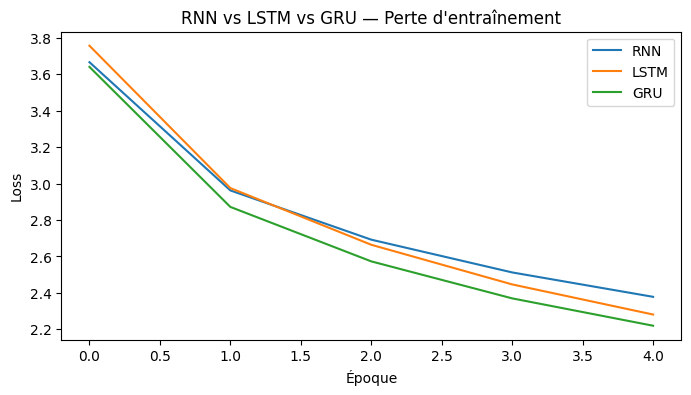

=== Coût de calcul (temps d'entraînement) ===
RNN : 54.2 s
LSTM : 57.3 s
GRU : 56.6 s
[RNN] Époque 1/5 | Loss: 3.6621 | Perplexité: 38.94
[RNN] Époque 2/5 | Loss: 2.9594 | Perplexité: 19.29
[RNN] Époque 3/5 | Loss: 2.6900 | Perplexité: 14.73
[RNN] Époque 4/5 | Loss: 2.5119 | Perplexité: 12.33
[RNN] Époque 5/5 | Loss: 2.3799 | Perplexité: 10.80
[RNN] Époque 1/5 | Loss: 3.6662 | Perplexité: 39.10
[RNN] Époque 2/5 | Loss: 2.9611 | Perplexité: 19.32
[RNN] Époque 3/5 | Loss: 2.6906 | Perplexité: 14.74
[RNN] Époque 4/5 | Loss: 2.5120 | Perplexité: 12.33
[RNN] Époque 5/5 | Loss: 2.3790 | Perplexité: 10.79


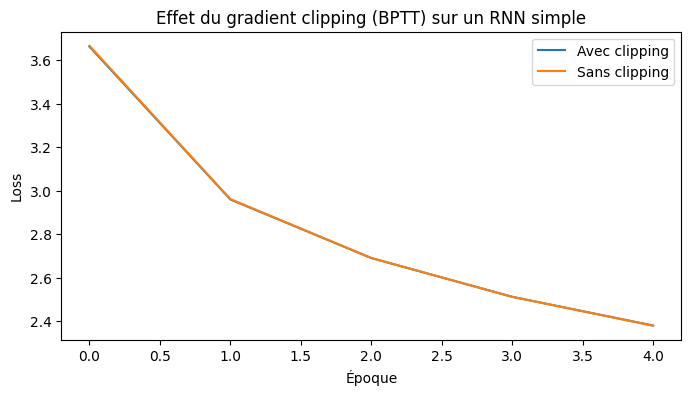

In [19]:
plt.figure(figsize=(8,4))
for rnn_type in results:
    plt.plot(results[rnn_type]['losses'], label=rnn_type)
plt.title("RNN vs LSTM vs GRU — Perte d'entraînement")
plt.xlabel("Époque"); plt.ylabel("Loss"); plt.legend()
plt.show()

print("=== Coût de calcul (temps d'entraînement) ===")
for rnn_type in results:
    print(f"{rnn_type} : {results[rnn_type]['duration']:.1f} s")

# Effet du gradient clipping sur le RNN simple (le plus instable)
_, losses_clip, _ = train_lm('RNN', clip_grad=True, num_epochs=5)
_, losses_noclip, _ = train_lm('RNN', clip_grad=False, num_epochs=5)

plt.figure(figsize=(8,4))
plt.plot(losses_clip, label='Avec clipping')
plt.plot(losses_noclip, label='Sans clipping')
plt.title("Effet du gradient clipping (BPTT) sur un RNN simple")
plt.xlabel("Époque"); plt.ylabel("Loss"); plt.legend()
plt.show()

In [20]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_token)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)

    def forward(self, x):
        emb = self.embedding(x)
        outputs, hidden = self.gru(emb)
        return outputs, hidden

In [21]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_token)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        emb = self.embedding(x)
        output, hidden = self.gru(emb, hidden)
        return self.fc(output), hidden

In [22]:
encoder = Encoder(eng.n_words).to(device)
decoder = Decoder(fra.n_words).to(device)
enc_opt = torch.optim.Adam(encoder.parameters(), lr=0.001)
dec_opt = torch.optim.Adam(decoder.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

teacher_forcing_ratio = 0.5
num_epochs = 10
seq2seq_losses = []

for epoch in range(num_epochs):
    total_loss = 0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        batch_size = src.size(0)
        enc_opt.zero_grad(); dec_opt.zero_grad()

        _, hidden = encoder(src)
        decoder_input = torch.full((batch_size, 1), SOS_token, device=device)
        loss = 0
        use_tf = random.random() < teacher_forcing_ratio

        for t in range(tgt.size(1)):
            output, hidden = decoder(decoder_input, hidden)
            loss += criterion(output.squeeze(1), tgt[:, t])
            decoder_input = tgt[:, t].unsqueeze(1) if use_tf else output.argmax(2)

        loss = loss / tgt.size(1)
        loss.backward()
        enc_opt.step(); dec_opt.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    seq2seq_losses.append(avg_loss)
    print(f"Époque {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Perplexité: {math.exp(avg_loss):.2f}")

Époque 1/10 | Loss: nan | Perplexité: nan
Époque 2/10 | Loss: nan | Perplexité: nan
Époque 3/10 | Loss: nan | Perplexité: nan
Époque 4/10 | Loss: nan | Perplexité: nan
Époque 5/10 | Loss: nan | Perplexité: nan
Époque 6/10 | Loss: nan | Perplexité: nan
Époque 7/10 | Loss: nan | Perplexité: nan
Époque 8/10 | Loss: nan | Perplexité: nan
Époque 9/10 | Loss: nan | Perplexité: nan
Époque 10/10 | Loss: nan | Perplexité: nan


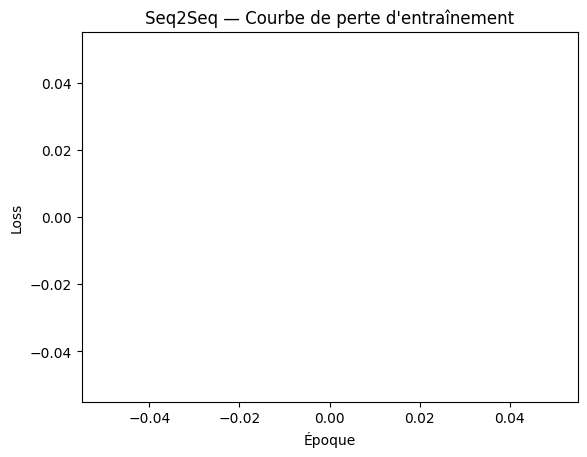

In [23]:
plt.plot(seq2seq_losses)
plt.title("Seq2Seq — Courbe de perte d'entraînement")
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.show()

In [24]:
def greedy_decode(sentence, max_length=12):
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        idx = sentence_to_indices(eng, normalize_string(sentence))
        idx = idx[:max_length] + [PAD_token]*(max_length-len(idx))
        src = torch.tensor(idx).unsqueeze(0).to(device)

        _, hidden = encoder(src)
        decoder_input = torch.tensor([[SOS_token]], device=device)
        words = []

        for _ in range(max_length):
            output, hidden = decoder(decoder_input, hidden)
            top_idx = output.argmax(2).item()
            if top_idx == EOS_token:
                break
            words.append(fra.index2word[top_idx])
            decoder_input = torch.tensor([[top_idx]], device=device)
    return ' '.join(words)

for s in [pairs[i][0] for i in range(5)]:
    print(f"EN : {s}")
    print(f"FR (prédit) : {greedy_decode(s)}\n")

EN : go .
FR (prédit) : va !

EN : run !
FR (prédit) : courez !

EN : run !
FR (prédit) : courez !

EN : wow !
FR (prédit) : felicitations !

EN : fire !
FR (prédit) : a voix !



In [25]:
def beam_search_decode(sentence, beam_width=3, max_length=12):
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        idx = sentence_to_indices(eng, normalize_string(sentence))
        idx = idx[:max_length] + [PAD_token]*(max_length-len(idx))
        src = torch.tensor(idx).unsqueeze(0).to(device)
        _, hidden = encoder(src)

        beams = [([SOS_token], 0.0, hidden)]   # (séquence, score, hidden)

        for _ in range(max_length):
            new_beams = []
            for seq, score, h in beams:
                if seq[-1] == EOS_token:
                    new_beams.append((seq, score, h)); continue
                decoder_input = torch.tensor([[seq[-1]]], device=device)
                output, h_new = decoder(decoder_input, h)
                log_probs = F.log_softmax(output.squeeze(1), dim=1)
                top_lp, top_idx = log_probs.topk(beam_width)

                for k in range(beam_width):
                    new_beams.append((seq + [top_idx[0,k].item()],
                                       score + top_lp[0,k].item(), h_new))

            new_beams.sort(key=lambda x: x[1], reverse=True)
            beams = new_beams[:beam_width]

        best_seq = beams[0][0]
        words = [fra.index2word[i] for i in best_seq if i not in (SOS_token, EOS_token, PAD_token)]
    return ' '.join(words)

for s in [pairs[i][0] for i in range(3)]:
    print(f"EN          : {s}")
    print(f"Greedy      : {greedy_decode(s)}")
    print(f"Beam search : {beam_search_decode(s, beam_width=3)}\n")

EN          : go .
Greedy      : va !
Beam search : allez !

EN          : run !
Greedy      : courez !
Beam search : courez !

EN          : run !
Greedy      : courez !
Beam search : courez !



In [26]:
def bleu_score_simple(reference, candidate, max_n=2):
    ref_tok, cand_tok = reference.split(), candidate.split()
    if not cand_tok:
        return 0.0
    precisions = []
    for n in range(1, max_n+1):
        ref_ngrams = Counter([tuple(ref_tok[i:i+n]) for i in range(len(ref_tok)-n+1)])
        cand_ngrams = Counter([tuple(cand_tok[i:i+n]) for i in range(len(cand_tok)-n+1)])
        overlap = sum((ref_ngrams & cand_ngrams).values())
        precisions.append(overlap / max(sum(cand_ngrams.values()), 1))
    geo_mean = np.prod(precisions) ** (1/len(precisions)) if all(precisions) else 0
    bp = min(1.0, math.exp(1 - len(ref_tok)/len(cand_tok)))
    return geo_mean * bp

scores = [bleu_score_simple(fra_s, greedy_decode(eng_s)) for eng_s, fra_s in pairs[:50]]
print(f"BLEU score moyen (50 exemples) : {np.mean(scores):.4f}")

BLEU score moyen (50 exemples) : 0.3211
